# 🦺 Detector de Equipo de Protección Personal (EPP)

**Autor:** Juan David Amaya Quintero  
**Asignatura:** Ciencia de Datos  

---

## 📌 Descripción

Este proyecto implementa un modelo de detección de objetos utilizando YOLOv8 para identificar elementos de protección personal (EPP) como cascos, chalecos y personas en imágenes.

El objetivo es aplicar técnicas de visión por computador en el ámbito de la seguridad industrial.

## 🧠 Introducción

La detección de objetos es una rama de la visión por computador que permite identificar y localizar múltiples objetos dentro de una imagen mediante bounding boxes.

A diferencia del reconocimiento de objetos, que solo clasifica, la detección permite saber qué objeto es y dónde está ubicado.

Este tipo de tecnologías se aplica en:

- Seguridad industrial
- Construcción
- Minería
- Supervisión automatizada

En este proyecto se implementa un detector de EPP (Equipo de Protección Personal).

In [1]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 131.4 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
import os
import matplotlib.pyplot as plt

In [3]:
rf = Roboflow(api_key="fPG2FpzdWgiAnvjaWdwd")

project = rf.workspace("hx-hezqh").project("ppe-detection-yfmym")
version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-Detection-1 in yolov8:: 100%|██████████| 4406/4406 [00:00<00:00, 5557.95it/s]


In [4]:
print("Archivos en el entorno:")
print(os.listdir())

Archivos en el entorno:
['.config', 'yolov8n.pt', 'runs', 'zidane.jpg', 'yolov5su.pt', 'PPE-Detection-1', 'sample_data']


## 📊 Dataset

El dataset utilizado corresponde a:

https://universe.roboflow.com/hx-hezqh/ppe-detection-yfmym

Este contiene imágenes anotadas para la detección de:

- helmet (casco)
- vest (chaleco)
- person (persona)

Estructura:

ppe-detection-1/
 ├── train/
 ├── valid/
 ├── test/
 ├── data.yaml

El formato YOLOv8 permite su integración directa con la librería Ultralytics.

In [7]:
import os
print(os.listdir())

['.config', 'yolov8n.pt', 'runs', 'zidane.jpg', 'yolov5su.pt', 'PPE-Detection-1', 'sample_data']


In [8]:
print(os.listdir("PPE-Detection-1"))

['README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'train', 'valid', 'test']


In [13]:
model = YOLO("yolov8n.pt")

In [14]:
model.train(
    data="PPE-Detection-1/data.yaml",
    epochs=30,
    imgsz=640
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=PPE-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dd5dc63e5a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [15]:
import os
print(os.listdir("runs/detect"))

['train-2', 'train-6', 'train-5', 'train-4', 'train-3', 'train', 'train-7']


In [16]:
model = YOLO("runs/detect/train-7/weights/best.pt")


image 1/211 /content/PPE-Detection-1/test/images/00048_jpg.rf.1b444ed4fa46924c9d227c3865a294ac.jpg: 640x640 1 helmet, 2 vests, 11.2ms
image 2/211 /content/PPE-Detection-1/test/images/00100_jpg.rf.6db1fdd5b22dce6d02ecd3c5aed754a8.jpg: 640x640 2 helmets, 3 vests, 7.4ms
image 3/211 /content/PPE-Detection-1/test/images/00121_jpg.rf.b345fd5828724b57773a5c3d909f23a0.jpg: 640x640 1 vest, 11.7ms
image 4/211 /content/PPE-Detection-1/test/images/00121_jpg.rf.bcddea93e0fd4636dec917dcf4fb0c66.jpg: 640x640 1 human, 1 vest, 12.2ms
image 5/211 /content/PPE-Detection-1/test/images/00125_jpg.rf.160774ca34d5eb6500b70f12f8e1f24c.jpg: 640x640 1 boots, 1 human, 1 vest, 7.2ms
image 6/211 /content/PPE-Detection-1/test/images/00126_jpg.rf.24bdd7abc9496a0a71f494c23e3cf64a.jpg: 640x640 1 human, 1 vest, 7.2ms
image 7/211 /content/PPE-Detection-1/test/images/00126_jpg.rf.baff51ab3163d3be6b38e2af5f79a45b.jpg: 640x640 1 human, 1 vest, 8.1ms
image 8/211 /content/PPE-Detection-1/test/images/00137_jpg.rf.d9d7d26c10fe

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

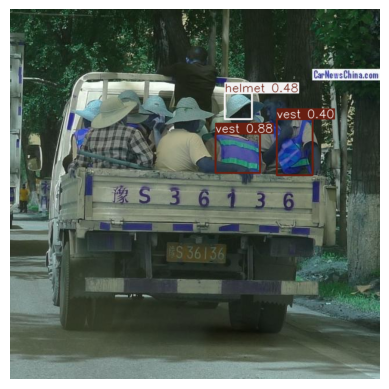

In [17]:
results = model("PPE-Detection-1/test/images")

import matplotlib.pyplot as plt

img = results[0].plot()
plt.imshow(img)
plt.axis("off")

In [18]:
import os

os.makedirs("proyecto", exist_ok=True)

In [19]:
import shutil

shutil.copy(
    "runs/detect/train-7/weights/best.pt",
    "proyecto/best.pt"
)

'proyecto/best.pt'

In [20]:
print(os.listdir("proyecto"))

['best.pt']


In [1]:
from google.colab import files
files.download("runs/detect/train-7/weights/best.pt")

ModuleNotFoundError: No module named 'google.colab'